In [1]:
import pandas as pd

In [2]:
a=3

In [3]:
import numpy as np
import os

# before: path = "../../data/processed/"
path = "data/processed"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)
df1 = None
df2 = None
# keep the odds from the dataframe

# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# index SamplingOperations_code
# df = df.set_index('SamplingOperations_code')


# sort by Date_SamplingOperation
df = df.sort_values(by='Date_SamplingOperation')

# df = df[['CodeSite_SamplingOperations_x', 'Date_SamplingOperation', 'IBD', 'Longitude_Lambert93', 'Latitude_Lambert93']]
# DROP HERlvl2Code	Altitude Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code
# df = df.drop(columns=['HERlvl2Code', 'HERlvl2Name', 'HERlvl1Name', 'Altitude','Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement', 'Date_SamplingOperation'])

In [4]:
# replace dateSamplingOperation for interger representing the date as YYYYMMDD
# convert to datetime first
df['Date_SamplingOperation'] = pd.to_datetime(df['Date_SamplingOperation'], format='%Y-%m-%d')
# then convert to integer YYYYMMDD
df['Date_SamplingOperation'] = df['Date_SamplingOperation'].dt.strftime('%Y%m%d').astype(int)

pd.set_option('display.max_columns', None)
df

SamplingOperations_code CodeSite_SamplingOperations_x  \
2703       S02115200_20070702                     S02115200   
33984      S05218450_20070709                     S05218450   
33929      S05217350_20070709                     S05217350   
48228      S05235850_20070709                     S05235850   
35408      S05234290_20070709                     S05234290   
...                       ...                           ...   
42720      S06580577_20230907                     S06580577   
35760      S06001284_20230907                     S06001284   
35783      S06001533_20230907                     S06001533   
38878      S06137040_20231011                     S06137040   
38873      S06137014_20231011                     S06137014   

       Date_SamplingOperation  TotalAbundance_SamplingOperation  Achaa01  \
2703                 20070702                               400      NaN   
33984                20070709                               400      NaN   
33929                20070709                               400      NaN   
48228                20070709                               400      NaN   
35408                20070709                               400      NaN   
...                       ...                               ...      ...   
42720                20230907                               426      NaN   
35760                20230907                               421      NaN   
35783                20230907                               401      NaN   
38878                20231011                               400      NaN   
38873                20231011                               405      NaN   

       Achac01  Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
2703       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984      NaN     12.5      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      2.5      NaN      NaN      NaN      NaN      NaN   
35408      NaN      7.5      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35760      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38878      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38873      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

         Achat02  Achat03  Achba01  Achbi01  Achbi02  Achbr01  Achca01  \
2703         NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929   5.000000      NaN      NaN      NaN      NaN      NaN      NaN   
48228  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
35408  20.000000      NaN      NaN      NaN      NaN      NaN      NaN   
...          ...      ...      ...      ...      ...      ...      ...   
42720   4.694836      NaN      NaN      NaN      NaN      NaN      NaN   
35760        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783  14.962594      NaN      NaN      NaN      NaN      NaN      NaN   
38878  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
38873  69.135802      NaN      NaN      NaN      NaN      NaN      NaN   

       Achca02  Achca03  Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
2703       NaN      NaN      NaN      NaN      NaN      NaN     12.5      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
42720      NaN 

In [5]:
# # drop Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code	HERlvl1Name	HERlvl2Code	HERlvl2Name	Altitude
# df = df.drop(columns=['Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement','HERlvl1Code','HERlvl1Name','HERlvl2Code','HERlvl2Name','Altitude', 'IBD_EQR', 'IBD_EQR_Status'])

In [6]:
df = df.drop(columns=['IBD_EQR', 'IBD_EQR_Status'])

In [10]:
df = df.drop(columns=['CodeSite_SamplingOperations_x'])


## No validation set

In [7]:
import numpy as np
import pandas as pd
from typing import Tuple, Optional
from catboost import CatBoostRegressor

def fit_catboost_and_fill(
    cleandf: pd.DataFrame,
    target: str = "IBD",
    base: Optional[dict] = None,         # e.g., {"loss_function":"RMSE","iterations":1500,"learning_rate":0.03,"depth":8}
    cat_params: Optional[dict] = None,
    use_ohe: bool = False                # False = native categoricals (recommended)
) -> Tuple[CatBoostRegressor, pd.DataFrame]:
    """
    Train on all rows with known target, then predict target for rows with NaN.
    Drops ['IBD','IBD_EQR','IBD_EQR_Status'] from features if present.
    Returns (fitted_model, scored_df) where scored_df = rows with NaN target + target_pred.
    """

    # 1) split into train/score by target presence
    df_train = cleandf[cleandf[target].notna()].copy()
    df_score = cleandf[cleandf[target].isna()].copy()

    # 2) drop leakage columns
    drop_cols = [c for c in ["IBD", "IBD_EQR", "IBD_EQR_Status"] if c in cleandf.columns]

    X = df_train.drop(columns=drop_cols + [target], errors="ignore")
    y = df_train[target].astype(float)

    # 3) detect dtypes
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    # 4) light preprocessing
    # numeric: leave NaN (CatBoost handles); categorical: fill with "(missing)"
    X_num = X[num_cols].copy()
    X_cat = X[cat_cols].copy().fillna("(missing)")

    if use_ohe:
        X_cat = pd.get_dummies(X_cat, drop_first=False)
        X_tr_proc = pd.concat([X_num.reset_index(drop=True),
                               X_cat.reset_index(drop=True)], axis=1)
        cat_features = None
    else:
        X_tr_proc = pd.concat([X_num.reset_index(drop=True),
                               X_cat.reset_index(drop=True)], axis=1)
        cat_features = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

    # 5) params and fit on ALL training data (no eval_set, no early stopping)
    base_params = base
    if cat_params:
        base_params.update(cat_params)

    model = CatBoostRegressor(**base_params)

    fit_kwargs = dict(X=X_tr_proc, y=y, use_best_model=False)
    if not use_ohe:
        fit_kwargs["cat_features"] = cat_features
    model.fit(**fit_kwargs)

    # 6) score NaN-target rows
    if df_score.empty:
        scored_df = pd.DataFrame(columns=list(cleandf.columns) + [f"{target}_pred"])
        return model, scored_df

    Xs = df_score.drop(columns=drop_cols + [target], errors="ignore")
    Xs_num = Xs[num_cols].copy()
    Xs_cat = Xs[cat_cols].copy().fillna("(missing)")

    if use_ohe:
        Xs_cat = pd.get_dummies(Xs_cat, drop_first=False)
        Xs_cat = Xs_cat.reindex(columns=X_cat.columns, fill_value=0)
        Xs_proc = pd.concat([Xs_num.reset_index(drop=True),
                             Xs_cat.reset_index(drop=True)], axis=1)
    else:
        Xs_proc = pd.concat([Xs_num.reset_index(drop=True),
                             Xs_cat.reset_index(drop=True)], axis=1)

    df_score[f"{target}_pred"] = model.predict(Xs_proc)
    scored_df = df_score

    return model, scored_df

# Validation set

In [8]:
# ===================== CatBoost (Regression) + FULL DIAGNOSTICS =====================
# pip install catboost scikit-learn matplotlib
# optional: pip install scipy shap

import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple, Dict, Any, Optional
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import style
style.mpl_apply()


try:
    from scipy import stats as _scipy_stats
except Exception:
    _scipy_stats = None

def _safe_ax(title: str, xlabel: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    return fig, ax

def _maybe_save(fig, outdir: Optional[Path], name: str, dpi: int = 140):
    if outdir:
        outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / f"{name}.png", bbox_inches="tight", dpi=dpi)

def _topn(series: pd.Series, k: int = 25) -> pd.Series:
    s = series.sort_values(ascending=False)
    return s.iloc[: min(k, len(s))]

def train_catboost_region_tunueado(
    cleandf: pd.DataFrame,
    target: str = "IBD",
    base: Optional[dict] = None,
    test_size: float = 0.10,
    random_state: int = 863,
    cat_params: Optional[dict] = None,
    use_ohe: bool = False,
    plots: bool = True,
    outdir: Optional[str] = None,
    perm_repeats: int = 10,
    perm_max_samples: int = 4000,
    shap_max_samples: int = 3000,
) -> Tuple["CatBoostRegressor", Dict[str, Any], pd.DataFrame, Dict[str, Any]]:
    """
    Train CatBoostRegressor with a validation split and produce exhaustive diagnostics.

    Returns:
        model: fitted CatBoostRegressor
        metrics: dict with train/valid metrics and overfitting gap
        scored_df: rows with missing target, with target_pred column if any
        artifacts: dict with evaluation results, feature importances, figures
                   keys: evals, figs, fi_split, fi_perm, preds_train, preds_valid
    """
    from catboost import CatBoostRegressor

    outdir_p = Path(outdir) if outdir else None

    # -----------------------------
    # 1) split train/score
    # -----------------------------
    df_train = cleandf[cleandf[target].notna()].copy()
    df_score = cleandf[cleandf[target].isna()].copy()

    drop_cols = [c for c in ["IBD", "IBD_EQR", "IBD_EQR_Status"] if c in cleandf.columns]

    X = df_train.drop(columns=drop_cols + [target], errors="ignore")
    y = df_train[target].astype(float)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # -----------------------------
    # 2) numeric / categorical
    # -----------------------------
    num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_tr.select_dtypes(exclude=[np.number]).columns.tolist()

    # -----------------------------
    # 3) light imputations
    # -----------------------------
    # numeric: leave NaN (CatBoost handles); categorical: '(missing)'
    X_tr_num = X_tr[num_cols].copy()
    X_te_num = X_te[num_cols].copy()

    X_tr_cat = X_tr[cat_cols].copy().fillna("(missing)")
    X_te_cat = X_te[cat_cols].copy().fillna("(missing)")

    if use_ohe:
        X_tr_cat = pd.get_dummies(X_tr_cat, drop_first=False)
        X_te_cat = pd.get_dummies(X_te_cat, drop_first=False)
        X_tr_cat, X_te_cat = X_tr_cat.align(X_te_cat, join="left", axis=1, fill_value=0)
        X_tr_proc = pd.concat([X_tr_num.reset_index(drop=True),
                               X_tr_cat.reset_index(drop=True)], axis=1)
        X_te_proc = pd.concat([X_te_num.reset_index(drop=True),
                               X_te_cat.reset_index(drop=True)], axis=1)
        cat_features = None
        feature_names = list(X_tr_proc.columns)
    else:
        X_tr_proc = pd.concat([X_tr_num.reset_index(drop=True),
                               X_tr_cat.reset_index(drop=True)], axis=1)
        X_te_proc = pd.concat([X_te_num.reset_index(drop=True),
                               X_te_cat.reset_index(drop=True)], axis=1)
        cat_features = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
        feature_names = num_cols + cat_cols

    # -----------------------------
    # 4) parameters
    # -----------------------------
    base_defaults = dict(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=5000,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3.0,
        random_seed=random_state,
        od_type="Iter",   # early stopping
        od_wait=200,
        bootstrap_type="Bayesian",
        bagging_temperature=0.2,
        verbose=200,
        allow_writing_files=False,
        grow_policy="Lossguide",
        min_data_in_leaf=16,
    )
    base_params = dict(base_defaults)
    if base:
        base_params.update(base)
    if cat_params:
        base_params.update(cat_params)

    model = CatBoostRegressor(**base_params)

    # -----------------------------
    # 5) fit with eval_set
    # -----------------------------
    fit_kwargs = dict(
        X=X_tr_proc, y=y_tr,
        eval_set=(X_te_proc, y_te),
        use_best_model=True,
    )
    if not use_ohe:
        fit_kwargs["cat_features"] = cat_features

    model.fit(**fit_kwargs)

    # -----------------------------
    # 6) metrics
    # -----------------------------
    pred_tr = model.predict(X_tr_proc)
    pred_te = model.predict(X_te_proc)

    def _rmse(y_true, y_hat):
        return float(np.sqrt(mean_squared_error(y_true, y_hat)))

    r2_tr = float(r2_score(y_tr, pred_tr))
    r2_te = float(r2_score(y_te, pred_te))
    rmse_tr = _rmse(y_tr, pred_tr)
    rmse_te = _rmse(y_te, pred_te)
    mae_tr = float(mean_absolute_error(y_tr, pred_tr))
    mae_te = float(mean_absolute_error(y_te, pred_te))

    best_iter = int(model.get_best_iteration() or model.tree_count_)
    metrics = {
        "R2_train": r2_tr,
        "R2_valid": r2_te,
        "MAE_train": mae_tr,
        "MAE_valid": mae_te,
        "RMSE_train": rmse_tr,
        "RMSE_valid": rmse_te,
        "best_iterations": best_iter,
        "gap_R2": float(r2_tr - r2_te),
        "gap_RMSE": float(rmse_te - rmse_tr),
        "used_ohe": bool(use_ohe),
        "n_train": int(len(y_tr)),
        "n_valid": int(len(y_te)),
        "n_features": int(len(feature_names)),
    }

    # -----------------------------
    # 7) score rows without target
    # -----------------------------
    if not df_score.empty:
        Xs = df_score.drop(columns=drop_cols + [target], errors="ignore")
        Xs_num = Xs[num_cols].copy()
        Xs_cat = Xs[cat_cols].copy().fillna("(missing)")
        if use_ohe:
            Xs_cat = pd.get_dummies(Xs_cat, drop_first=False)
            Xs_cat = Xs_cat.reindex(columns=X_tr_cat.columns, fill_value=0)
            Xs_proc = pd.concat([Xs_num.reset_index(drop=True),
                                 Xs_cat.reset_index(drop=True)], axis=1)
        else:
            Xs_proc = pd.concat([Xs_num.reset_index(drop=True),
                                 Xs_cat.reset_index(drop=True)], axis=1)
        df_score[target + "_pred"] = model.predict(Xs_proc)
        scored_df = df_score
    else:
        scored_df = pd.DataFrame(columns=list(cleandf.columns) + [target + "_pred"])

    # -----------------------------
    # 8) diagnostics: eval curves, residuals, importances, SHAP (optional)
    # -----------------------------
    artifacts: Dict[str, Any] = {}
    figs: Dict[str, Any] = {}

    # 8.1 learning curves
    evals = model.get_evals_result()
    artifacts["evals"] = evals
    if plots and evals and "learn" in evals and "validation" in evals:
        for metric_name in evals["learn"].keys():
            learn_vals = evals["learn"][metric_name]
            valid_vals = evals["validation"][metric_name]
            fig, ax = _safe_ax(f"Learning curve ({metric_name})",
                               "Iteration", metric_name)
            ax.plot(range(1, len(learn_vals) + 1), learn_vals, label="train")
            ax.plot(range(1, len(valid_vals) + 1), valid_vals, label="valid")
            ax.axvline(best_iter, ls="--", alpha=0.5, label="best_iter")
            ax.legend()
            _maybe_save(fig, outdir_p, f"curve_{metric_name}")
            figs[f"curve_{metric_name}"] = fig

    # 8.2 predicted vs actual (train/valid)
    if plots:
        # train
        fig, ax = _safe_ax("Predicted vs Actual (train)", "Actual", "Predicted")
        ax.scatter(y_tr, pred_tr, s=8, alpha=0.35)
        lo = np.nanmin([y_tr.min(), pred_tr.min()])
        hi = np.nanmax([y_tr.max(), pred_tr.max()])
        ax.plot([lo, hi], [lo, hi], ls="--")
        _maybe_save(fig, outdir_p, "pva_train")
        figs["pva_train"] = fig

        # valid
        fig, ax = _safe_ax("Predicted vs Actual (valid)", "Actual", "Predicted")
        ax.scatter(y_te, pred_te, s=10, alpha=0.45)
        lo = np.nanmin([y_te.min(), pred_te.min()])
        hi = np.nanmax([y_te.max(), pred_te.max()])
        ax.plot([lo, hi], [lo, hi], ls="--")
        _maybe_save(fig, outdir_p, "pva_valid")
        figs["pva_valid"] = fig

    # 8.3 residual plots
    res_tr = y_tr - pred_tr
    res_te = y_te - pred_te
    artifacts["preds_train"] = pd.DataFrame({"y": y_tr, "yhat": pred_tr, "resid": res_tr}).reset_index(drop=True)
    artifacts["preds_valid"] = pd.DataFrame({"y": y_te, "yhat": pred_te, "resid": res_te}).reset_index(drop=True)

    if plots:
        # histograms
        fig, ax = _safe_ax("Residuals histogram (train/valid)", "Residual", "Count")
        ax.hist(res_tr, bins=50, alpha=0.5, label="train")
        ax.hist(res_te, bins=50, alpha=0.5, label="valid")
        ax.legend()
        _maybe_save(fig, outdir_p, "residual_hist")
        figs["residual_hist"] = fig

        # residual vs fitted (valid)
        fig, ax = _safe_ax("Residuals vs Fitted (valid)", "Fitted", "Residual")
        ax.scatter(pred_te, res_te, s=10, alpha=0.45)
        ax.axhline(0.0, ls="--")
        _maybe_save(fig, outdir_p, "residual_vs_fitted_valid")
        figs["residual_vs_fitted_valid"] = fig

        # QQ plot (valid)
        if _scipy_stats is not None:
            fig = plt.figure(figsize=(5.0, 5.0))
            _scipy_stats.probplot(res_te, dist="norm", plot=plt)
            plt.title("QQ-plot of residuals (valid)")
            _maybe_save(fig, outdir_p, "qqplot_valid")
            figs["qqplot_valid"] = fig

    # 8.4 feature importance (split-based from CatBoost)
    try:
        fi_pretty = model.get_feature_importance(type="FeatureImportance",
                                                 prettified=True)
        fi_split = pd.DataFrame(fi_pretty)
        # ensure consistent column names
        if "Feature Id" in fi_split.columns and "Importance" in fi_split.columns:
            fi_split = fi_split.rename(columns={"Feature Id": "feature",
                                                "Importance": "importance"})
        elif set(["Feature Id", "Importances"]).issubset(fi_split.columns):
            fi_split = fi_split.rename(columns={"Feature Id": "feature",
                                                "Importances": "importance"})
        artifacts["fi_split"] = fi_split
        if plots and not fi_split.empty:
            top = _topn(fi_split.set_index("feature")["importance"], 30)
            fig, ax = _safe_ax("Feature importance (split-based, top 30)",
                               "Importance", "Feature")
            ax.barh(top.index[::-1], top.values[::-1])
            _maybe_save(fig, outdir_p, "fi_split_top30")
            figs["fi_split_top30"] = fig
    except Exception:
        artifacts["fi_split"] = pd.DataFrame(columns=["feature", "importance"])

    # 8.6 SHAP summary (optional)
    if plots:
        try:
            import shap
            # small sample for speed; use processed matrices to match model expectation
            if len(X_te_proc) > shap_max_samples:
                rng = np.random.default_rng(random_state)
                idx = rng.choice(len(X_te_proc), size=shap_max_samples, replace=False)
                X_shap = X_te_proc.iloc[idx]
            else:
                X_shap = X_te_proc

            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_shap)
            # summary plot
            fig = plt.figure(figsize=(7.0, 5.0))
            shap.summary_plot(shap_values, X_shap, show=False, max_display=25)
            plt.title("SHAP summary (valid sample)")
            _maybe_save(fig, outdir_p, "shap_summary")
            figs["shap_summary"] = fig
            artifacts["shap_sample_size"] = int(len(X_shap))
        except Exception:
            pass

    artifacts["figs"] = figs

    return model, metrics, scored_df, artifacts


# Tobit Style Correction

In [15]:
# ===================== CatBoost (Regression) + Censoring + Full Diagnostics =====================
import numpy as np, pandas as pd
from pathlib import Path
from typing import Tuple, Dict, Any, Optional
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from scripts import style
style.mpl_apply()

try:
    from scipy import stats as _scipy_stats
except Exception:
    _scipy_stats = None

def _phi(z): return np.exp(-0.5*z*z)/np.sqrt(2*np.pi)
def _Phi(z):
    import math
    return 0.5*(1.0 + np.vectorize(math.erf)(z/np.sqrt(2.0)))

def _safe_ax(title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(6.5,4.0))
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.grid(True, alpha=0.25)
    return fig, ax

def _maybe_save(fig, outdir: Optional[Path], name: str, dpi: int = 140):
    if outdir: outdir.mkdir(parents=True, exist_ok=True); fig.savefig(outdir/f"{name}.png", bbox_inches="tight", dpi=dpi)

def _topn(series: pd.Series, k: int = 25) -> pd.Series:
    s = series.sort_values(ascending=False); return s.iloc[:min(k, len(s))]

def _build_mats(dfX: pd.DataFrame, drop_cols: list, target: str,
                use_ohe: bool, num_cols_ref=None, cat_cols_ref=None,
                ohe_cols_ref=None):
    """Return X_proc, feature_names, cat_features, metadata. Guarantees [num | cat] order."""
    X = dfX.drop(columns=drop_cols+[target], errors="ignore")

    # detect cols or reuse ref
    if num_cols_ref is None or cat_cols_ref is None:
        num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = X.columns.difference(num_cols).tolist()
    else:
        num_cols, cat_cols = list(num_cols_ref), list(cat_cols_ref)

    # keep order: all numerics first, then categoricals
    X_num = X[num_cols].copy()
    X_cat = X[cat_cols].copy().fillna("(missing)")

    if use_ohe:
        X_cat = pd.get_dummies(X_cat, drop_first=False)
        if ohe_cols_ref is not None:
            X_cat = X_cat.reindex(columns=ohe_cols_ref, fill_value=0)
        X_proc = pd.concat([X_num.reset_index(drop=True),
                            X_cat.reset_index(drop=True)], axis=1)
        feature_names = list(X_proc.columns)
        cat_features = None
        meta = dict(num_cols=num_cols, cat_cols=cat_cols, ohe_cols=list(X_cat.columns))
    else:
        X_proc = pd.concat([X_num.reset_index(drop=True),
                            X_cat.reset_index(drop=True)], axis=1)
        feature_names = num_cols + cat_cols
        cat_features = list(range(len(num_cols), len(num_cols)+len(cat_cols)))
        meta = dict(num_cols=num_cols, cat_cols=cat_cols, ohe_cols=None)

    return X_proc, feature_names, cat_features, meta

def train_catboost_region_tunueado_censored(
    cleandf: pd.DataFrame,
    target: str = "IBD",
    base: Optional[dict] = None,
    test_size: float = 0.10,
    random_state: int = 863,
    cat_params: Optional[dict] = None,
    use_ohe: bool = False,
    plots: bool = True,
    outdir: Optional[str] = None,
    shap_max_samples: int = 3000,
    # censoring
    censor_value: float = 20.0,
    sigma_method: str = "mad",
    eps: float = 1e-12,
) -> Tuple["CatBoostRegressor", Dict[str, Any], pd.DataFrame, Dict[str, Any]]:
    from catboost import CatBoostRegressor

    outdir_p = Path(outdir) if outdir else None

    # 1) robust target coercion
    df_y = cleandf[cleandf[target].notna()].copy()
    df_score = cleandf[cleandf[target].isna()].copy()
    y_num = pd.to_numeric(df_y[target], errors="coerce")
    non_numeric_dropped = int(y_num.isna().sum())
    if non_numeric_dropped:
        df_y = df_y.loc[y_num.notna()].copy()
        y_num = y_num.loc[y_num.notna()]
    df_y[target] = y_num.astype(float)

    mask_unc = df_y[target] < float(censor_value)
    df_unc, df_cens = df_y.loc[mask_unc].copy(), df_y.loc[~mask_unc].copy()

    drop_cols = [c for c in ["IBD", "IBD_EQR", "IBD_EQR_Status"] if c in cleandf.columns]

    # 2) matrices for UNCENSORED
    X_unc_proc, feat_names, cat_features, meta = _build_mats(
        df_unc, drop_cols, target, use_ohe,
    )

    # 3) split and fit
    from sklearn.model_selection import train_test_split
    y_unc = df_unc[target].astype(float)
    X_tr, X_te, y_tr, y_te = train_test_split(X_unc_proc, y_unc, test_size=test_size, random_state=random_state)

    base_defaults = dict(
        loss_function="RMSE", eval_metric="RMSE",
        iterations=5000, learning_rate=0.05, depth=8, l2_leaf_reg=3.0,
        random_seed=random_state, od_type="Iter", od_wait=200,
        bootstrap_type="Bayesian", bagging_temperature=0.2,
        verbose=200, allow_writing_files=False,
        grow_policy="Lossguide", min_data_in_leaf=16,
    )
    params = {**base_defaults, **(base or {}), **(cat_params or {})}
    model = CatBoostRegressor(**params)
    fit_kwargs = dict(X=X_tr, y=y_tr, eval_set=(X_te, y_te), use_best_model=True)
    if not use_ohe: fit_kwargs["cat_features"] = cat_features
    model.fit(**fit_kwargs)

    # 4) uncensored metrics
    def _rmse(y_true, y_hat): return float(np.sqrt(mean_squared_error(y_true, y_hat)))
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
    r2_tr, r2_te = float(r2_score(y_tr, pred_tr)), float(r2_score(y_te, pred_te))
    rmse_tr, rmse_te = _rmse(y_tr, pred_tr), _rmse(y_te, pred_te)
    mae_tr, mae_te = float(mean_absolute_error(y_tr, pred_tr)), float(mean_absolute_error(y_te, pred_te))
    best_iter = int(model.get_best_iteration() or model.tree_count_)

    # 5) sigma for correction
    resid_tr = y_tr - pred_tr
    if sigma_method.lower() == "mad":
        med = float(np.median(resid_tr)); sigma = 1.4826 * float(np.median(np.abs(resid_tr - med)))
    else:
        sigma = float(np.std(resid_tr, ddof=1))
    sigma = max(sigma, 1e-3)

    def _tobit_correct(yhat: np.ndarray, c: float, s: float) -> np.ndarray:
        z = (c - yhat) / s
        tail = _phi(z) / np.maximum(1.0 - _Phi(z), eps)
        return np.where(yhat < c, yhat, c + s * tail)

    pred_te_corr = _tobit_correct(pred_te, censor_value, sigma)

    # 6) score rows without target (align to training)
    def _proc_like_train(dfX: pd.DataFrame) -> pd.DataFrame:
        return _build_mats(
            dfX, drop_cols, target, use_ohe,
            num_cols_ref=meta["num_cols"], cat_cols_ref=meta["cat_cols"],
            ohe_cols_ref=meta["ohe_cols"],
        )[0]

    if not df_score.empty:
        Xs_proc = _proc_like_train(df_score)
        yhat_raw = model.predict(Xs_proc)
        yhat_corr = _tobit_correct(yhat_raw, censor_value, sigma)
        df_score[target+"_pred_raw"]  = yhat_raw
        df_score[target+"_pred_corr"] = yhat_corr
        scored_df = df_score
    else:
        scored_df = pd.DataFrame(columns=list(cleandf.columns)+[target+"_pred_raw", target+"_pred_corr"])

    # 7) diagnostics
    artifacts, figs = {}, {}
    evals = model.get_evals_result(); artifacts["evals"] = evals
    if plots and evals and "learn" in evals and "validation" in evals:
        for metric_name in evals["learn"].keys():
            fig, ax = _safe_ax(f"Learning curve ({metric_name})","Iteration",metric_name)
            ax.plot(range(1,len(evals["learn"][metric_name])+1), evals["learn"][metric_name], label="train")
            ax.plot(range(1,len(evals["validation"][metric_name])+1), evals["validation"][metric_name], label="valid")
            ax.axvline(best_iter, ls="--", alpha=0.5, label="best_iter"); ax.legend()
            _maybe_save(fig, outdir_p, f"curve_{metric_name}"); figs[f"curve_{metric_name}"]=fig

    if plots:
        fig, ax = _safe_ax("PVA (train, uncensored)","Actual","Predicted")
        ax.scatter(y_tr, pred_tr, s=8, alpha=0.35)
        lo = float(np.nanmin([y_tr.min(), pred_tr.min()])); hi = float(np.nanmax([y_tr.max(), pred_tr.max(), censor_value]))
        ax.plot([lo,hi],[lo,hi], ls="--"); ax.axvline(censor_value, color="r", alpha=0.4); ax.axhline(censor_value, color="r", alpha=0.4)
        _maybe_save(fig, outdir_p, "pva_train_unc"); figs["pva_train_unc"]=fig

        fig, ax = _safe_ax("PVA (valid, uncensored) raw vs corr","Actual","Predicted")
        ax.scatter(y_te, pred_te, s=10, alpha=0.45, label="raw")
        ax.scatter(y_te, pred_te_corr, s=10, alpha=0.45, label="corr", marker="x")
        ax.plot([lo,hi],[lo,hi], ls="--"); ax.axvline(censor_value, color="r", alpha=0.4); ax.axhline(censor_value, color="r", alpha=0.4)
        ax.legend(); _maybe_save(fig, outdir_p, "pva_valid_unc"); figs["pva_valid_unc"]=fig

        res_te = y_te - pred_te
        fig, ax = _safe_ax("Residuals hist (uncensored)","Residual","Count")
        ax.hist(y_tr - pred_tr, bins=50, alpha=0.5, label="train"); ax.hist(res_te, bins=50, alpha=0.5, label="valid")
        ax.legend(); _maybe_save(fig, outdir_p, "residual_hist_unc"); figs["residual_hist_unc"]=fig

        fig, ax = _safe_ax("Residuals vs Fitted (valid, uncensored)","Fitted","Residual")
        ax.scatter(pred_te, res_te, s=10, alpha=0.45); ax.axhline(0.0, ls="--")
        _maybe_save(fig, outdir_p, "residual_vs_fitted_valid_unc"); figs["residual_vs_fitted_valid_unc"]=fig

        if _scipy_stats is not None:
            fig = plt.figure(figsize=(5,5)); _scipy_stats.probplot(res_te, dist="norm", plot=plt)
            plt.title("QQ-plot (valid, uncensored)"); _maybe_save(fig, outdir_p, "qqplot_valid_unc"); figs["qqplot_valid_unc"]=fig

        # target censoring diagnostic
        fig, ax = _safe_ax("Target distribution with censoring", target, "Count")
        ax.hist(df_y[target], bins=80, alpha=0.7); ax.axvline(censor_value, color="r", lw=2, label=f"censor={censor_value}")
        ax.legend(); _maybe_save(fig, outdir_p, "target_censor_hist"); figs["target_censor_hist"]=fig

    # feature importance
    try:
        fi_pretty = model.get_feature_importance(type="FeatureImportance", prettified=True)
        fi = pd.DataFrame(fi_pretty)
        if "Feature Id" in fi.columns and "Importance" in fi.columns:
            fi = fi.rename(columns={"Feature Id":"feature","Importance":"importance"})
        elif set(["Feature Id","Importances"]).issubset(fi.columns):
            fi = fi.rename(columns={"Feature Id":"feature","Importances":"importance"})
        if plots and not fi.empty:
            top = _topn(fi.set_index("feature")["importance"], 30)
            fig, ax = _safe_ax("Feature importance (top 30)","Importance","Feature")
            ax.barh(top.index[::-1], top.values[::-1]); _maybe_save(fig, outdir_p, "fi_split_top30"); figs["fi_split_top30"]=fig
    except Exception:
        fi = pd.DataFrame(columns=["feature","importance"])

    artifacts = {
        "figs": figs,
        "fi_split": fi,
        "censor_stats": {
            "censor_value": float(censor_value),
            "n_uncensored_used": int(len(df_unc)),
            "n_censored_observed": int(len(df_cens)),
            "n_non_numeric_dropped": int(non_numeric_dropped),
            "sigma_resid": float(sigma),
        }
    }

    metrics = {
        "R2_train_unc": r2_tr, "R2_valid_unc": r2_te,
        "MAE_train_unc": mae_tr, "MAE_valid_unc": mae_te,
        "RMSE_train_unc": rmse_tr, "RMSE_valid_unc": rmse_te,
        "best_iterations": best_iter,
        "gap_R2_unc": float(r2_tr - r2_te),
        "gap_RMSE_unc": float(rmse_te - rmse_tr),
        "used_ohe": bool(use_ohe),
        "n_train_unc": int(len(y_tr)), "n_valid_unc": int(len(y_te)),
        "n_features": int(len(feat_names)),
    }

    return model, metrics, scored_df, artifacts


# Training

In [16]:
from catboost.utils import get_gpu_device_count
print("GPUs visible to CatBoost:", get_gpu_device_count())

GPUs visible to CatBoost: 1


In [12]:
base_opt = dict(
    task_type="GPU",
    devices="0",

    # Objetivo
    loss_function="RMSE",
    eval_metric="RMSE",

    # Iteraciones largas con parada temprana robusta
    iterations=10000,
    learning_rate=0.02,          # más bajo, más estable
    od_type="Iter",
    od_wait=300,                 # mayor paciencia para curvas ruidosas
    random_seed=863,

    # Complejidad y estructura
    depth=20,                     # menos overfitting que 10
    grow_policy="Lossguide",     # útil para muchas columnas
    min_data_in_leaf=80,         # hojas más estables

    # Regularización
    l2_leaf_reg=1,             # controla peso L2 en hojas
    random_strength=1,         # aleatoriedad en splits
    bagging_temperature=1,     # menor => más determinista, mejor generalización
    # subsample=0.8,               # añade bagging (en GPU lo soporta)
    # colsample_bylevel=0.8,       # reducción dimensional regularizadora

    # Binning y ruido
    max_bin=321,                 # binning fino mejora precisión en datos densos
    
    # Logging
    verbose=500
)


In [13]:
import os
from pathlib import Path
name ="Truncated02"
outdir=f"visualizations/Catboost_TPEPM{name}"
# CREATE OUTPUT DIRECTORY IF IT DOESN'T EXIST
Path(outdir).mkdir(parents=True, exist_ok=True)

0:	learn: 2.4175614	test: 2.4319623	best: 2.4319623 (0)	total: 52ms	remaining: 8m 39s
500:	learn: 0.5226369	test: 0.6539030	best: 0.6539030 (500)	total: 15s	remaining: 4m 44s
1000:	learn: 0.4075638	test: 0.5647434	best: 0.5647434 (1000)	total: 30.3s	remaining: 4m 32s
1500:	learn: 0.3504605	test: 0.5290396	best: 0.5290396 (1500)	total: 46.1s	remaining: 4m 20s
2000:	learn: 0.3126663	test: 0.5088338	best: 0.5088338 (2000)	total: 1m 2s	remaining: 4m 11s
2500:	learn: 0.2839997	test: 0.4957300	best: 0.4957300 (2500)	total: 1m 18s	remaining: 3m 55s
3000:	learn: 0.2611717	test: 0.4866883	best: 0.4866883 (3000)	total: 1m 36s	remaining: 3m 45s
3500:	learn: 0.2419280	test: 0.4805273	best: 0.4805273 (3500)	total: 1m 54s	remaining: 3m 33s
4000:	learn: 0.2247695	test: 0.4754369	best: 0.4754369 (4000)	total: 2m 12s	remaining: 3m 18s
4500:	learn: 0.2099000	test: 0.4713530	best: 0.4713530 (4500)	total: 2m 29s	remaining: 3m 2s
5000:	learn: 0.1964030	test: 0.4679901	best: 0.4679901 (5000)	total: 2m 47s	r

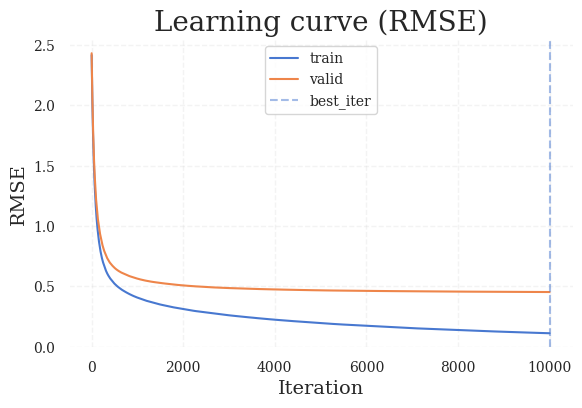

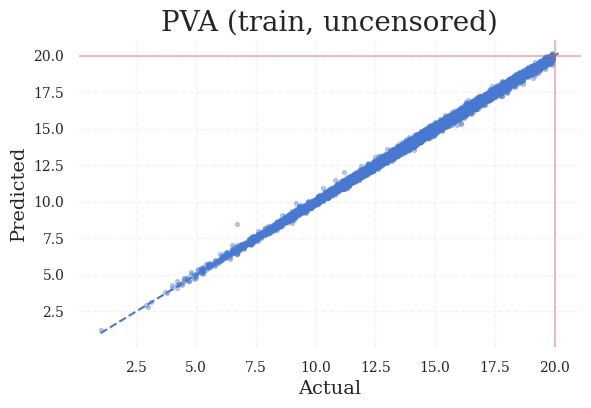

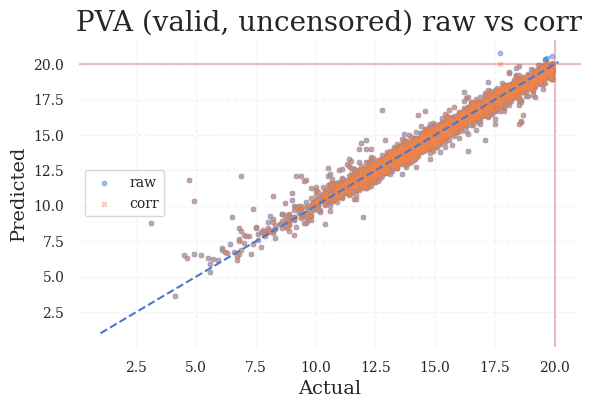

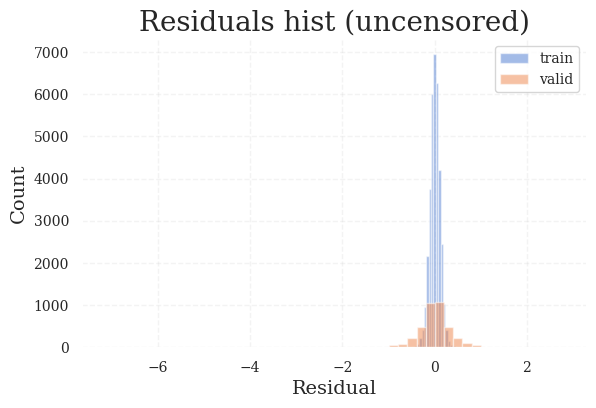

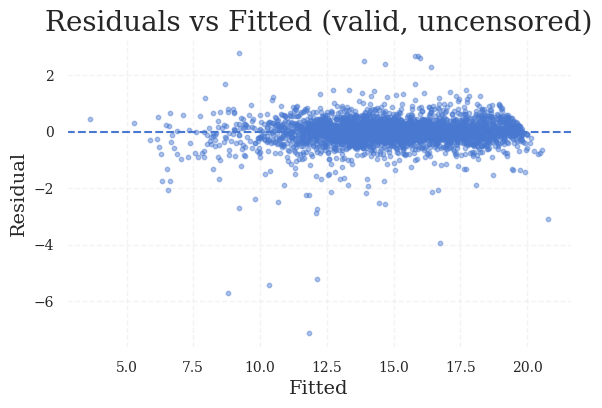

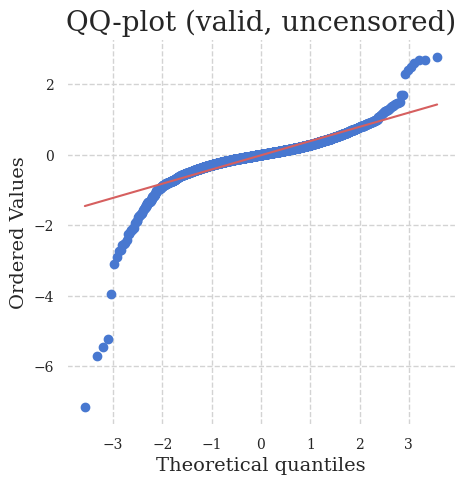

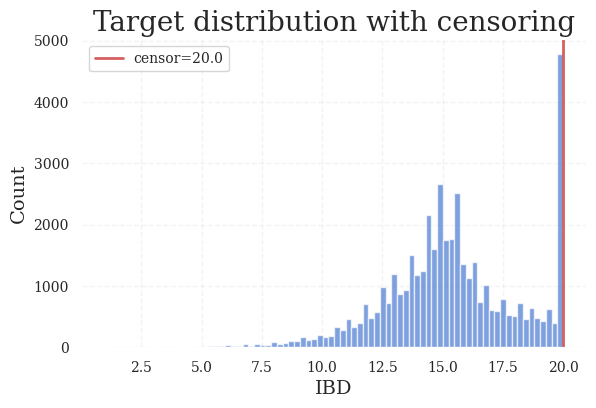

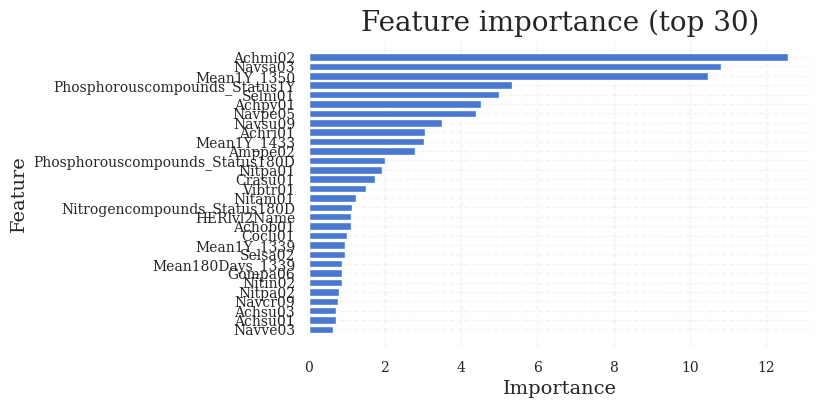

In [16]:
model, metrics, scored_df, artifacts = train_catboost_region_tunueado_censored(
    cleandf=df,
    target="IBD",
    censor_value=20.0,
    base=base_opt,
    outdir="visualizations/Catboost_TPEPM{name}",
)

In [23]:
print(artifacts)


{'figs': {'curve_RMSE': <Figure size 650x400 with 1 Axes>, 'pva_train_unc': <Figure size 650x400 with 1 Axes>, 'pva_valid_unc': <Figure size 650x400 with 1 Axes>, 'residual_hist_unc': <Figure size 650x400 with 1 Axes>, 'residual_vs_fitted_valid_unc': <Figure size 650x400 with 1 Axes>, 'qqplot_valid_unc': <Figure size 500x500 with 1 Axes>, 'target_censor_hist': <Figure size 650x400 with 1 Axes>, 'fi_split_top30': <Figure size 650x400 with 1 Axes>}, 'fi_split':                             feature  importance
0                           Achmi02   12.576012
1                           Navsa03   10.812299
2                       Mean1Y_1350   10.467232
3     Phosphorouscompounds_Status1Y    5.337102
4                           Selni01    4.988465
...                             ...         ...
2844                    Mean1Y_1770    0.000000
2845                    Mean1Y_6249    0.000000
2846                Mean90Days_2923    0.000000
2847                Mean90Days_6249    0.000000
2848    

In [24]:
print(metrics)
# Figures available in art["figs"], saved under ./cb_diagnostics/*.png if outdir provided
# Split-based importance: art["fi_split"]; Permutation importance: art["fi_perm"]

{'R2_train_unc': 0.9979488217279655, 'R2_valid_unc': 0.9659833388837628, 'MAE_train_unc': 0.08566743163824478, 'MAE_valid_unc': 0.27376089181523444, 'RMSE_train_unc': 0.11088354345985162, 'RMSE_valid_unc': 0.45386538828629736, 'best_iterations': 9999, 'gap_R2_unc': 0.03196548284420275, 'gap_RMSE_unc': 0.3429818448264457, 'used_ohe': False, 'n_train_unc': 35244, 'n_valid_unc': 3916, 'n_features': 2849}


In [19]:
scored_df

SamplingOperations_code  Date_SamplingOperation  \
48228      S05235850_20070709                20070709   
47256      S05113000_20070723                20070723   
47024      S05082000_20070724                20070724   
47237      S05111500_20070724                20070724   
47042      S05086000_20070725                20070725   
...                       ...                     ...   
48719      S06173650_20230720                20230720   
48450      S06076420_20230726                20230726   
49198      S06830139_20230818                20230818   
48775      S06178000_20230822                20230822   
49200      S06830142_20230830                20230830   

       TotalAbundance_SamplingOperation  Achaa01  Achac01  Achaf01  Achaf02  \
48228                               400      NaN      NaN      2.5      NaN   
47256                               433      NaN      NaN      NaN      NaN   
47024                               400      NaN      NaN      NaN      NaN   
47237                               414      NaN      NaN      NaN      NaN   
47042                               424      NaN      NaN      NaN      NaN   
...                                 ...      ...      ...      ...      ...   
48719                               416      NaN      NaN      NaN      NaN   
48450                               399      NaN      NaN      NaN      NaN   
49198                               394      NaN      NaN      NaN      NaN   
48775                               411      NaN      NaN      NaN      NaN   
49200                               404      NaN      NaN      NaN      NaN   

       Achal01  Acham01  Achan01  Achat01    Achat02  Achat03  Achba01  \
48228      NaN      NaN      NaN      NaN  42.500000      NaN      NaN   
47256      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
47024      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
47237      NaN      NaN      NaN      NaN   2.415459      NaN      NaN   
47042      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
...        ...      ...      ...      ...        ...      ...      ...   
48719      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
48450      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
49198      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
48775      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
49200      NaN      NaN      NaN      NaN        NaN      NaN      NaN   

       Achbi01  Achbi02  Achbr01  Achca01  Achca02  Achca03  Achca04  Achch01  \
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
47256      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
47024      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
47237      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
47042      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
48719      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48450      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
49198      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48775      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
49200      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

       Achcl01  Achco01  Achco02  Achco03  Achco04  Achcr01  Achcy01  Achda01  \
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
47256      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
47024      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
47237      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
47042      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ... 

In [20]:
scored_df = scored_df[['SamplingOperations_code','IBD_pred_corr']]
# rename IBD_pred to IBD_EQR_Status
scored_df.rename(columns={'IBD_pred':'IBD_EQR_Status'}, inplace=True)

C:\Users\herie\AppData\Local\Temp\ipykernel_2264\1338188445.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scored_df.rename(columns={'IBD_pred':'IBD_EQR_Status'}, inplace=True)


In [21]:
scored_df.to_csv(f'results/015_Catboost2/015_Catboost2_TPEPM{name}.csv', index=False)

In [22]:
# save the model joblib
import joblib
joblib.dump(model, f'results/015_Catboost2/015_Catboost2_TPEPM{name}.joblib', compress=3)

['results/015_Catboost2/015_Catboost2_TPEPMTruncated02.joblib']